In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.metrics import *

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [56]:
df = pd.read_csv('/content/Walmart DataSet.csv')

In [57]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [59]:
df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%Y')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [61]:
df.set_index('Date', inplace = True)

In [62]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106


In [63]:
df['Month'] = df.index.month
df['Year'] = df.index.year

In [64]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
Date,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [65]:
df['Economic_Stress_Index'] = df['Fuel_Price'] * df['CPI']

In [66]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Economic_Stress_Index
Date,,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,542.939833
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,538.245049
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,531.180905
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,541.189605
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,554.794125


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6435 entries, 2010-02-05 to 2012-10-26
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store                  6435 non-null   int64  
 1   Weekly_Sales           6435 non-null   float64
 2   Holiday_Flag           6435 non-null   int64  
 3   Temperature            6435 non-null   float64
 4   Fuel_Price             6435 non-null   float64
 5   CPI                    6435 non-null   float64
 6   Unemployment           6435 non-null   float64
 7   Month                  6435 non-null   int32  
 8   Year                   6435 non-null   int32  
 9   Economic_Stress_Index  6435 non-null   float64
dtypes: float64(6), int32(2), int64(2)
memory usage: 502.7 KB


In [68]:
df_scaled = df.copy()

In [69]:
sc = StandardScaler()
for col in df_scaled.columns:
  df_scaled[col] = sc.fit_transform(df_scaled[[col]])

In [70]:
df_scaled.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Economic_Stress_Index
Date,,,,,,,,,,
2010-02-05,-1.693979,1.057420,-0.274204,-0.995136,-1.713800,1.004175,0.056964,-1.373525,-1.210899,-0.212553
2010-02-12,-1.693979,1.054348,3.646917,-1.201170,-1.766089,1.007880,0.056964,-1.373525,-1.210899,-0.245549
2010-02-19,-1.693979,1.001206,-0.274204,-1.124178,-1.840166,1.009074,0.056964,-1.373525,-1.210899,-0.295198
2010-02-26,-1.693979,0.642828,-0.274204,-0.760907,-1.737766,1.009849,0.056964,-1.373525,-1.210899,-0.224854
2010-03-05,-1.693979,0.899914,-0.274204,-0.767955,-1.598328,1.010624,0.056964,-1.064698,-1.210899,-0.129237


In [71]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Economic_Stress_Index
Date,,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,542.939833
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,538.245049
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,531.180905
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,541.189605
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,554.794125


In [72]:
X = df.drop(['Weekly_Sales'], axis = 1)
y = df['Weekly_Sales']

In [73]:
estimator = LinearRegression()
rfe = RFE(estimator=estimator, n_features_to_select=5)
rfe.fit(X, y)
feature_ranking = pd.Series(rfe.ranking_, index=X.columns)
selected_features = X.columns[rfe.support_]
print("Feature Ranking:", feature_ranking.sort_values())
print("Selected Features:", selected_features)

Feature Ranking: Store                    1
Holiday_Flag             1
Fuel_Price               1
Unemployment             1
Year                     1
Month                    2
CPI                      3
Economic_Stress_Index    4
Temperature              5
dtype: int64
Selected Features: Index(['Store', 'Holiday_Flag', 'Fuel_Price', 'Unemployment', 'Year'], dtype='object')


In [74]:
estimator = LinearRegression()
rfe = RFE(estimator = estimator, n_features_to_select = 9)
rfe.fit(X,y)

RFE(estimator=LinearRegression(), n_features_to_select=9)

In [75]:
feature_ranking = pd.Series(rfe.ranking_, index = X.columns)
selected_features = X.columns[rfe.support_]

In [76]:
print('Feature Ranking:', feature_ranking.sort_values())
print('Selected Features:', selected_features)

Feature Ranking: Store                    1
Holiday_Flag             1
Temperature              1
Fuel_Price               1
CPI                      1
Unemployment             1
Month                    1
Year                     1
Economic_Stress_Index    1
dtype: int64
Selected Features: Index(['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Month', 'Year', 'Economic_Stress_Index'],
      dtype='object')


<Axes: title={'center': 'Feature Ranking by RFE'}>

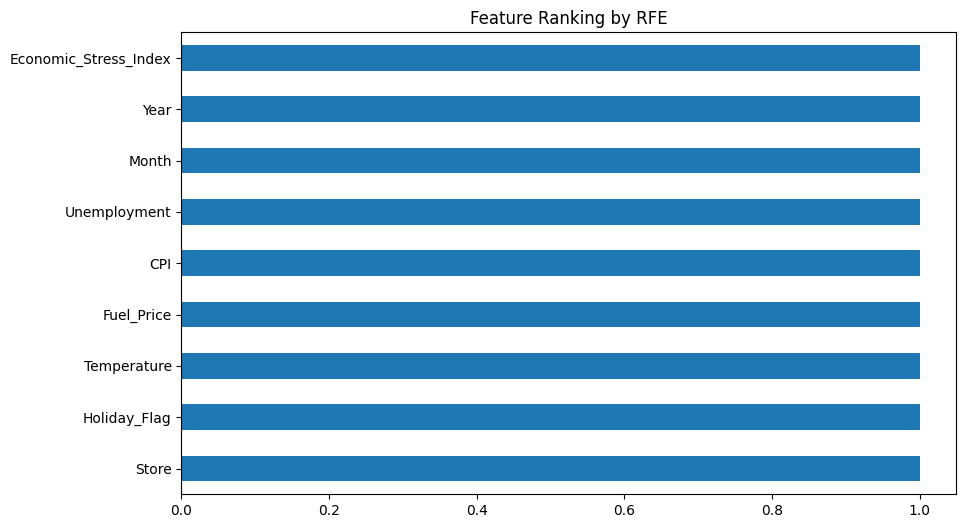

In [77]:
feature_ranking.sort_values().plot.barh(figsize=(10, 6), title='Feature Ranking by RFE')

In [78]:
new_X = df[selected_features]

In [79]:
new_X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Economic_Stress_Index
Date,,,,,,,,,
2010-02-05,1,0,42.31,2.572,211.096358,8.106,2,2010,542.939833
2010-02-12,1,1,38.51,2.548,211.242170,8.106,2,2010,538.245049
2010-02-19,1,0,39.93,2.514,211.289143,8.106,2,2010,531.180905
2010-02-26,1,0,46.63,2.561,211.319643,8.106,2,2010,541.189605
2010-03-05,1,0,46.50,2.625,211.350143,8.106,3,2010,554.794125


**Unemployment Impact**

In [80]:
overall_unemployment = df['Weekly_Sales'].corr(df['Unemployment'])
print("Overall Unemployment Impact:", overall_unemployment)

Overall Unemployment Impact: -0.10617608965795429


In [81]:
store_unemployment = df.groupby('Store')['Weekly_Sales'].corr(df['Unemployment'])

In [82]:
worst_store_unemployment = store_unemployment.idxmin()
print("Store with the Worst Unemployment Impact:", worst_store_unemployment)

Store with the Worst Unemployment Impact: 38


In [83]:
best_store_unemployment = store_unemployment.idxmax()
print("Store with the Best Unemployment Impact:", best_store_unemployment)

Store with the Best Unemployment Impact: 36


In [84]:
print(f"Top 5 worst hit stores are: {store_unemployment.sort_values().head()}")

Top 5 worst hit stores are: Store
38   -0.211947
44   -0.206916
39   -0.103134
17   -0.093961
41   -0.091569
Name: Weekly_Sales, dtype: float64


In [85]:
print(f"Top 5 best hit stores are: {store_unemployment.sort_values(ascending=False).head()}")

Top 5 best hit stores are: Store
36    0.229796
14    0.117463
35    0.099362
30    0.065431
43    0.064713
Name: Weekly_Sales, dtype: float64


**Seasonal Trend**

In [86]:
avg_monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

In [87]:
print(avg_monthly_sales)

Month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64


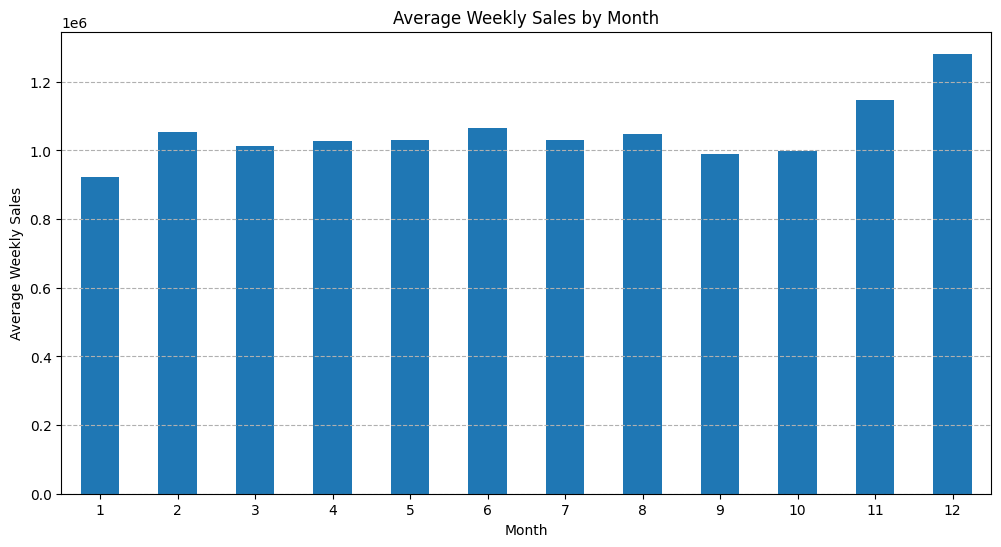

In [88]:
plt.figure(figsize=(12, 6))
avg_monthly_sales.plot(kind='bar')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

In [89]:
average_sales_by_holiday = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print("Average Weekly Sales by Holiday:", average_sales_by_holiday)

Average Weekly Sales by Holiday: Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


In [90]:
monthly_holiday_sales = df.groupby(['Month', 'Holiday_Flag'])['Weekly_Sales'].mean().unstack()
print(monthly_holiday_sales.head)

<bound method NDFrame.head of Holiday_Flag             0             1
Month                                   
1             9.238846e+05           NaN
2             1.044557e+06  1.079128e+06
3             1.013309e+06           NaN
4             1.026762e+06           NaN
5             1.031714e+06           NaN
6             1.064325e+06           NaN
7             1.031748e+06           NaN
8             1.048017e+06           NaN
9             9.734078e+05  1.042427e+06
10            9.996321e+05           NaN
11            1.039263e+06  1.471273e+06
12            1.362121e+06  9.608331e+05>


<Figure size 1400x700 with 0 Axes>

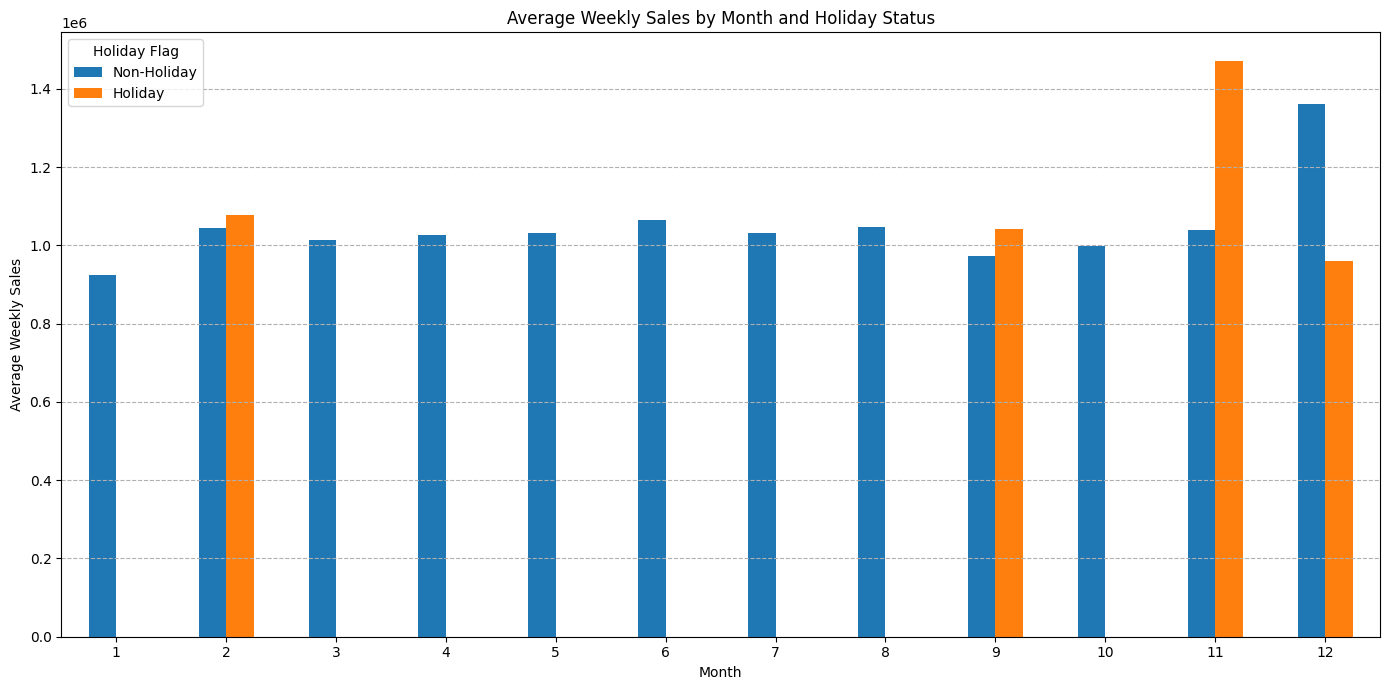

In [91]:
plt.figure(figsize=(14, 7))
monthly_holiday_sales.fillna(0).plot(kind='bar', figsize=(14, 7))
plt.title('Average Weekly Sales by Month and Holiday Status')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=0)
plt.legend(title='Holiday Flag', labels=['Non-Holiday', 'Holiday'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

As per the plot, Holidays does make an impact on the Weekly Sales. Sales of February, September, November and December have been affected by it.

**Temperature Impact**

In [92]:
temperature_correlation = df['Weekly_Sales'].corr(df['Temperature'])
print("Temperature Impact on Weekly Sales:", temperature_correlation)

Temperature Impact on Weekly Sales: -0.06381001317946956


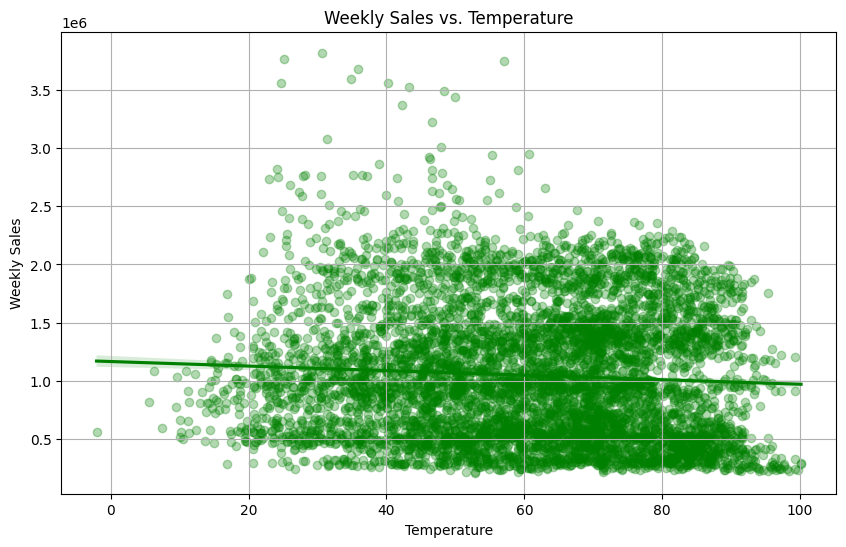

In [93]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Temperature', y='Weekly_Sales', data=df, scatter_kws={'alpha':0.3}, color= 'green')
plt.title('Weekly Sales vs. Temperature')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

**CPI Impact**

In [94]:
CPI_correlation = df['Weekly_Sales'].corr(df['CPI'])
print("CPI Impact on Weekly Sales:", CPI_correlation)

CPI Impact on Weekly Sales: -0.07263416204017631


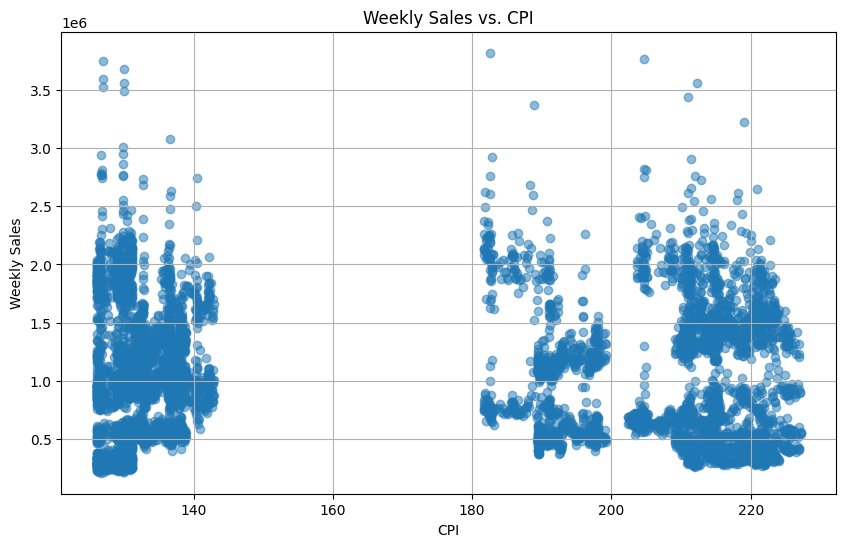

In [95]:
plt.figure(figsize=(10, 6))
plt.scatter(df['CPI'], df['Weekly_Sales'], alpha=0.5)
plt.title('Weekly Sales vs. CPI')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

**Best and Worst Performing Stores**

In [96]:
store_performance = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
print(store_performance)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64


In [97]:
top_performing_store = store_performance.idxmax()
worst_performing_store = store_performance.idxmin()
print("Top Performing Store:", top_performing_store)
print("Worst Performing Store:", worst_performing_store)

Top Performing Store: 20
Worst Performing Store: 33


**Prediction for the next 12 Months**

In [98]:
store_id = int(input("Please enter a Store ID (an integer from 1 to 45): "))
prediction_length = 12
print(f"Selected Store ID: {store_id}")
print(f"Prediction length set to: {prediction_length} weeks")

Please enter a Store ID (an integer from 1 to 45): 13
Selected Store ID: 13
Prediction length set to: 12 weeks


In [99]:
store_df = df[df['Store'] == store_id].copy()

In [100]:
store_df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Economic_Stress_Index
Date,,,,,,,,,,
2010-02-05,13,1967220.53,0,31.53,2.666,126.442065,8.316,2,2010,337.094544
2010-02-12,13,2030933.46,1,33.16,2.671,126.496258,8.316,2,2010,337.871505
2010-02-19,13,1970274.64,0,35.70,2.654,126.526286,8.316,2,2010,335.800762
2010-02-26,13,1817850.32,0,29.98,2.667,126.552286,8.316,2,2010,337.514946
2010-03-05,13,1939980.43,0,40.65,2.681,126.578286,8.316,3,2010,339.356384


In [101]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 143 entries, 2010-02-05 to 2012-10-26
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store                  143 non-null    int64  
 1   Weekly_Sales           143 non-null    float64
 2   Holiday_Flag           143 non-null    int64  
 3   Temperature            143 non-null    float64
 4   Fuel_Price             143 non-null    float64
 5   CPI                    143 non-null    float64
 6   Unemployment           143 non-null    float64
 7   Month                  143 non-null    int32  
 8   Year                   143 non-null    int32  
 9   Economic_Stress_Index  143 non-null    float64
dtypes: float64(6), int32(2), int64(2)
memory usage: 11.2 KB


In [102]:
store_weekly_sales = store_df['Weekly_Sales']

**Check for Stationarity**

In [103]:
adfuller_result = adfuller(store_weekly_sales)
print(f'ADF Statistic: {adfuller_result[0]}')
print(f'p-value: {adfuller_result[1]}')
if adfuller_result[1] > 0.05:
    print("The series is non-stationary.")
else:
    print("The series is stationary.")

ADF Statistic: -5.502481711233357
p-value: 2.05644619369346e-06
The series is stationary.


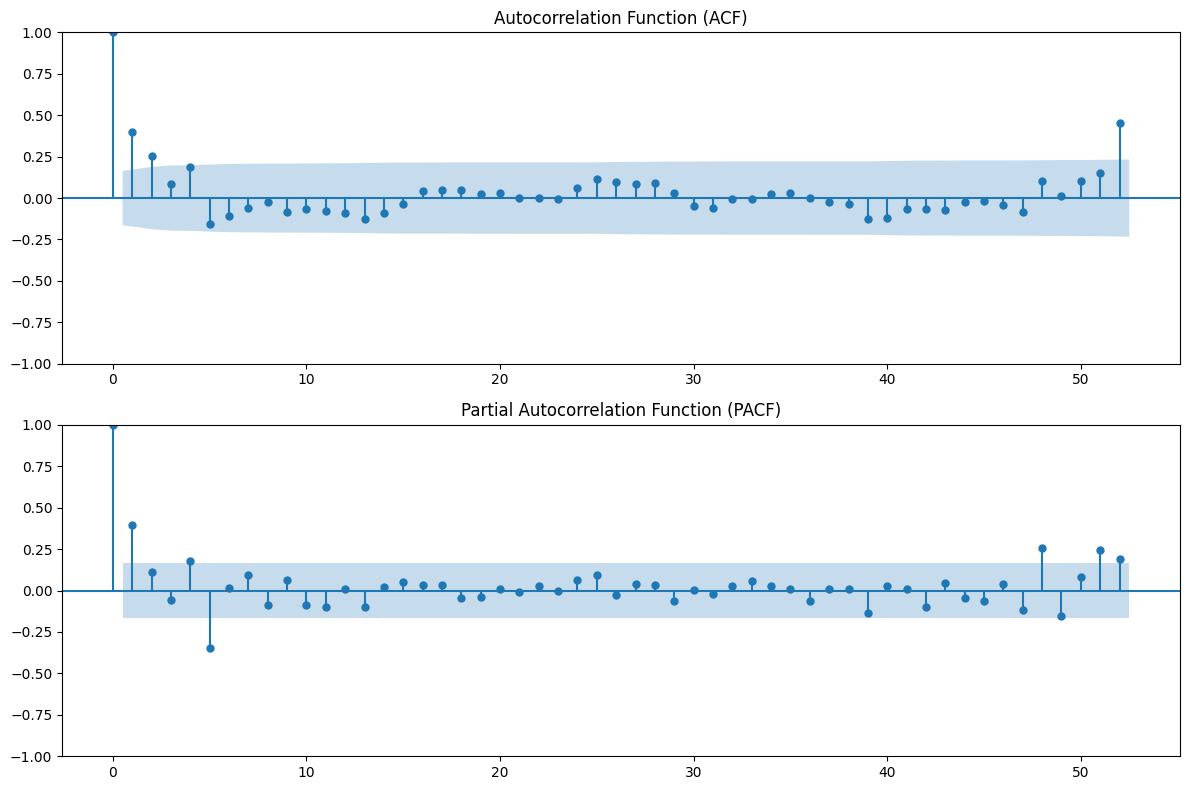

In [104]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(store_weekly_sales, lags=52, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(store_weekly_sales, lags=52, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

In [105]:
model = SARIMAX(store_weekly_sales, order=(1,0,1), seasonal_order=(0,1,0,52))
model_fit = model.fit(disp=False)
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 52)   Log Likelihood               -1188.957
Date:                             Fri, 13 Mar 2026   AIC                           2383.915
Time:                                     18:50:44   BIC                           2391.447
Sample:                                 02-05-2010   HQIC                          2386.954
                                      - 10-26-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5242      0.100     -5.224      0.000      -0.721      -0.328
ma.L1          0.8498      

In [106]:
future_predictions = model_fit.predict(start=len(store_weekly_sales), end=len(store_weekly_sales) + prediction_length - 1)
print(future_predictions.head(12))

2012-11-02    2.055110e+06
2012-11-09    2.101741e+06
2012-11-16    2.021488e+06
2012-11-23    2.861463e+06
2012-11-30    2.052735e+06
2012-12-07    2.462035e+06
2012-12-14    2.760737e+06
2012-12-21    3.556562e+06
2012-12-28    1.969164e+06
2013-01-04    1.865697e+06
2013-01-11    1.794992e+06
2013-01-18    1.811591e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [107]:
combined_sales = pd.concat([store_weekly_sales, future_predictions])
print(combined_sales.tail(15))

2012-10-12    1.999079e+06
2012-10-19    2.018010e+06
2012-10-26    2.035190e+06
2012-11-02    2.055110e+06
2012-11-09    2.101741e+06
2012-11-16    2.021488e+06
2012-11-23    2.861463e+06
2012-11-30    2.052735e+06
2012-12-07    2.462035e+06
2012-12-14    2.760737e+06
2012-12-21    3.556562e+06
2012-12-28    1.969164e+06
2013-01-04    1.865697e+06
2013-01-11    1.794992e+06
2013-01-18    1.811591e+06
dtype: float64


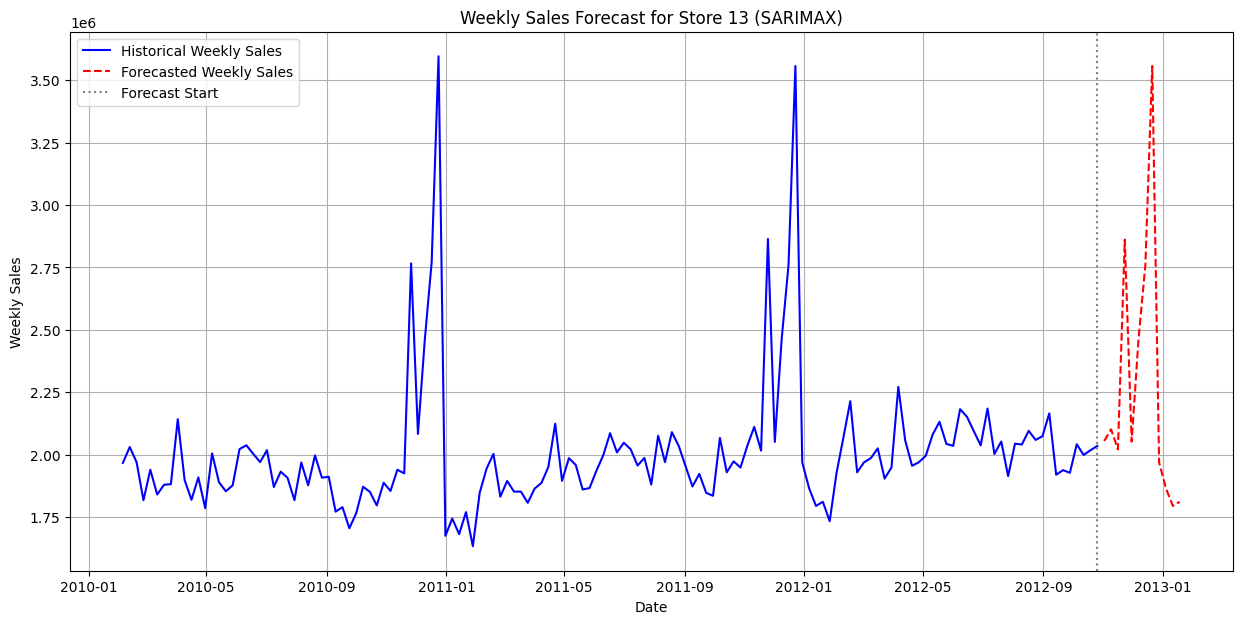

In [108]:
plt.figure(figsize=(15, 7))
plt.plot(store_weekly_sales.index, store_weekly_sales, label='Historical Weekly Sales', color='blue')
plt.plot(future_predictions.index, future_predictions, label='Forecasted Weekly Sales', color='red', linestyle='--')
plt.axvline(x=store_weekly_sales.index[-1], color='gray', linestyle=':', label='Forecast Start')
plt.title(f'Weekly Sales Forecast for Store {store_id} (SARIMAX)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()